Análisis operativo de atención en tiendas Coppel Puebla

Análisis Operativo de Atención en Tiendas: Tiempos de Espera, Eficiencia y Abandono

In [4]:
from google.colab import files
uploaded = files.upload()

Saving archive (1).zip to archive (1) (1).zip


In [6]:
# ============================================================
# PROYECTO 1: ANÁLISIS OPERATIVO DE ATENCIÓN EN TIENDAS
# Dataset: Puebla tiendas Coppel
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import zipfile
import os

In [7]:
# Ver archivos cargados
os.listdir()

['.config', 'archive (1) (1).zip', 'archive (1).zip', 'sample_data']

In [8]:
# Cambia el nombre si tu archivo aparece diferente
zip_file = "archive (1).zip"

with zipfile.ZipFile(zip_file, "r") as zip_ref:
    zip_ref.extractall("coppel_data")

os.listdir("coppel_data")

['puebla_tiendas_coppel.csv']

In [9]:
# Cargar dataset
df = pd.read_csv("coppel_data/puebla_tiendas_coppel.csv")

df.head()

,Unnamed: 0,Fecha,Segmento,hora_llegada,hora_llamado,hora_salida,caja,tienda,status,estado,tiempo_espera,tiempo_atencion,mismatch,mismatch_reason
0,567791,2023-01-02,banco,0.383535,0.415606,0.415699,ventanilla_a,Tienda_J,Atendido,Puebla,0.032072,0.000093,False,unico
1,567792,2023-01-02,banco,0.411289,0.415919,0.415988,ventanilla_a,Tienda_J,Atendido,Puebla,0.004630,0.000069,False,unico
2,567793,2023-01-02,retail,0.412655,0.415641,0.415919,caja_c,Tienda_J,Atendido,Puebla,0.002986,0.000278,False,unico
3,567794,2023-01-02,retail,0.415826,0.415826,0.415988,caja_f,Tienda_J,Atendido,Puebla,0.000000,0.000162,False,unico
4,567795,2023-01-02,banco,0.415919,0.416000,0.416046,ventanilla_a,Tienda_J,Atendido,Puebla,0.000081,0.000046,False,unico


In [10]:
# Revisión inicial
df.info()
df.describe(include="all")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1407325 entries, 0 to 1407324
Data columns (total 14 columns):
 #   Column           Non-Null Count    Dtype  
---  ------           --------------    -----  
 0   Unnamed: 0       1407325 non-null  int64  
 1   Fecha            1407325 non-null  object 
 2   Segmento         1407325 non-null  object 
 3   hora_llegada     1407325 non-null  float64
 4   hora_llamado     1407325 non-null  float64
 5   hora_salida      1407325 non-null  float64
 6   caja             1407325 non-null  object 
 7   tienda           1407325 non-null  object 
 8   status           1407325 non-null  object 
 9   estado           1407325 non-null  object 
 10  tiempo_espera    1407325 non-null  float64
 11  tiempo_atencion  1407325 non-null  float64
 12  mismatch         1407325 non-null  bool   
 13  mismatch_reason  1407325 non-null  object 
dtypes: bool(1), float64(5), int64(1), object(7)
memory usage: 140.9+ MB


,Unnamed: 0,Fecha,Segmento,hora_llegada,hora_llamado,hora_salida,caja,tienda,status,estado,tiempo_espera,tiempo_atencion,mismatch,mismatch_reason
count,1.407325e+06,1407325,1407325,1.407325e+06,1.407325e+06,1.407325e+06,1407325,1407325,1407325,1407325,1.407325e+06,1.407325e+06,1407325,1407325
unique,NaN,393,3,NaN,NaN,NaN,43,4,2,1,NaN,NaN,2,4
top,NaN,2023-12-16,retail,NaN,NaN,NaN,ventanilla_a,Tienda_BA,Atendido,Puebla,NaN,NaN,False,unico
freq,NaN,6089,684118,NaN,NaN,NaN,128494,420717,1334839,1407325,NaN,NaN,1311640,1311640
mean,9.705186e+06,NaN,NaN,6.097582e-01,6.126866e-01,6.144548e-01,NaN,NaN,NaN,NaN,2.928400e-03,2.074671e-03,NaN,NaN
std,5.498131e+06,NaN,NaN,1.142870e-01,1.143165e-01,1.148490e-01,NaN,NaN,NaN,NaN,5.088462e-03,2.697353e-03,NaN,NaN
min,3.172630e+05,NaN,NaN,3.487083e-01,3.505139e-01,1.300926e-03,NaN,NaN,NaN,NaN,0.000000e+00,1.157407e-05,NaN,NaN
25%,4.586685e+06,NaN,NaN,5.141366e-01,5.171458e-01,5.191134e-01,NaN,NaN,NaN,NaN,5.787037e-05,8.564815e-04,NaN,NaN
50%,9.468704e+06,NaN,NaN,6.109306e-01,6.143218e-01,6.162431e-01,NaN,NaN,NaN,NaN,1.018519e-03,1.446759e-03,NaN,NaN
75%,1.495763e+07,NaN,NaN,7.045417e-01,7.075625e-01,7.094954e-01,NaN,NaN,NaN,NaN,3.263889e-03,2.476852e-03,NaN,NaN


1. Limpieza y preparación

In [11]:
# Eliminar columna innecesaria si existe
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

# Convertir fecha
df["Fecha"] = pd.to_datetime(df["Fecha"])

# Crear columnas de tiempo
df["año"] = df["Fecha"].dt.year
df["mes"] = df["Fecha"].dt.month
df["mes_nombre"] = df["Fecha"].dt.month_name()
df["dia_semana"] = df["Fecha"].dt.day_name()
df["semana"] = df["Fecha"].dt.isocalendar().week
df["periodo_mes"] = df["Fecha"].dt.to_period("M").astype(str)

# Convertir tiempos a minutos
# En este dataset los tiempos parecen venir como fracción de día.
df["tiempo_espera_min"] = df["tiempo_espera"] * 24 * 60
df["tiempo_atencion_min"] = df["tiempo_atencion"] * 24 * 60

df.head()

,Fecha,Segmento,hora_llegada,hora_llamado,hora_salida,caja,tienda,status,estado,tiempo_espera,...,mismatch,mismatch_reason,año,mes,mes_nombre,dia_semana,semana,periodo_mes,tiempo_espera_min,tiempo_atencion_min
0,2023-01-02,banco,0.383535,0.415606,0.415699,ventanilla_a,Tienda_J,Atendido,Puebla,0.032072,...,False,unico,2023,1,January,Monday,1,2023-01,46.183333,0.133333
1,2023-01-02,banco,0.411289,0.415919,0.415988,ventanilla_a,Tienda_J,Atendido,Puebla,0.004630,...,False,unico,2023,1,January,Monday,1,2023-01,6.666667,0.100000
2,2023-01-02,retail,0.412655,0.415641,0.415919,caja_c,Tienda_J,Atendido,Puebla,0.002986,...,False,unico,2023,1,January,Monday,1,2023-01,4.300000,0.400000
3,2023-01-02,retail,0.415826,0.415826,0.415988,caja_f,Tienda_J,Atendido,Puebla,0.000000,...,False,unico,2023,1,January,Monday,1,2023-01,0.000000,0.233333
4,2023-01-02,banco,0.415919,0.416000,0.416046,ventanilla_a,Tienda_J,Atendido,Puebla,0.000081,...,False,unico,2023,1,January,Monday,1,2023-01,0.116667,0.066667


In [12]:
# Revisar valores únicos principales
for col in ["Segmento", "tienda", "status", "estado", "mismatch_reason"]:
    print(col)
    print(df[col].value_counts())
    print("-" * 40)

Segmento
Segmento
retail        684118
banco         629412
afiliacion     93795
Name: count, dtype: int64
----------------------------------------
tienda
tienda
Tienda_BA    420717
Tienda_AY    370751
Tienda_J     331108
Tienda_U     284749
Name: count, dtype: int64
----------------------------------------
status
status
Atendido    1334839
Ausente       72486
Name: count, dtype: int64
----------------------------------------
estado
estado
Puebla    1407325
Name: count, dtype: int64
----------------------------------------
mismatch_reason
mismatch_reason
unico           1311640
multitramite      92575
saturacion         2997
otro_caso           113
Name: count, dtype: int64
----------------------------------------


2. KPIs generales

In [13]:
total_registros = len(df)
clientes_atendidos = len(df[df["status"] == "Atendido"])
clientes_ausentes = len(df[df["status"] == "Ausente"])

tasa_atencion = clientes_atendidos / total_registros
tasa_abandono = clientes_ausentes / total_registros

tiempo_espera_promedio = df["tiempo_espera_min"].mean()
tiempo_atencion_promedio = df["tiempo_atencion_min"].mean()

print("KPIs GENERALES")
print("----------------------------------------")
print(f"Total de registros: {total_registros:,.0f}")
print(f"Clientes atendidos: {clientes_atendidos:,.0f}")
print(f"Clientes ausentes: {clientes_ausentes:,.0f}")
print(f"Tasa de atención: {tasa_atencion:.2%}")
print(f"Tasa de abandono: {tasa_abandono:.2%}")
print(f"Tiempo promedio de espera: {tiempo_espera_promedio:.2f} minutos")
print(f"Tiempo promedio de atención: {tiempo_atencion_promedio:.2f} minutos")

KPIs GENERALES
----------------------------------------
Total de registros: 1,407,325
Clientes atendidos: 1,334,839
Clientes ausentes: 72,486
Tasa de atención: 94.85%
Tasa de abandono: 5.15%
Tiempo promedio de espera: 4.22 minutos
Tiempo promedio de atención: 2.99 minutos


3. Análisis por tienda

In [14]:
tienda_kpis = df.groupby("tienda").agg(
    total_clientes=("status", "count"),
    clientes_atendidos=("status", lambda x: (x == "Atendido").sum()),
    clientes_ausentes=("status", lambda x: (x == "Ausente").sum()),
    tiempo_espera_promedio=("tiempo_espera_min", "mean"),
    tiempo_atencion_promedio=("tiempo_atencion_min", "mean")
).reset_index()

tienda_kpis["tasa_abandono"] = tienda_kpis["clientes_ausentes"] / tienda_kpis["total_clientes"]

tienda_kpis = tienda_kpis.sort_values("total_clientes", ascending=False)

tienda_kpis

,tienda,total_clientes,clientes_atendidos,clientes_ausentes,tiempo_espera_promedio,tiempo_atencion_promedio,tasa_abandono
1,Tienda_BA,420717,398756,21961,3.853201,3.474318,0.052199
0,Tienda_AY,370751,361248,9503,4.791490,2.951046,0.025632
2,Tienda_J,331108,303627,27481,3.471766,2.325166,0.082997
3,Tienda_U,284749,271208,13541,4.872564,3.085986,0.047554


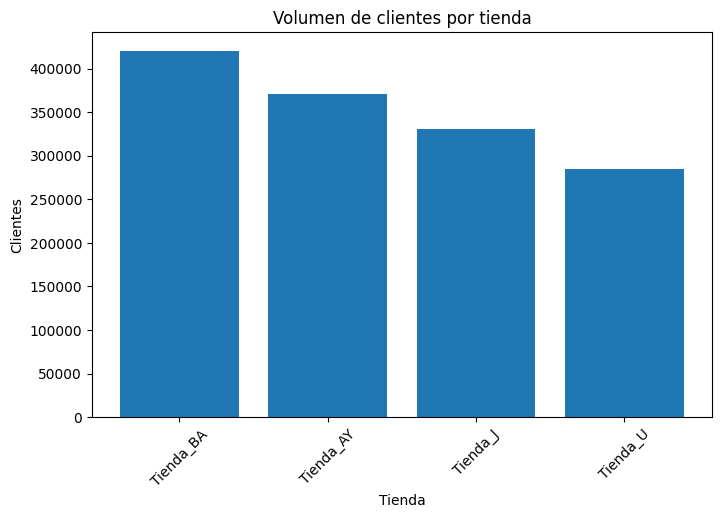

In [15]:
plt.figure(figsize=(8,5))
plt.bar(tienda_kpis["tienda"], tienda_kpis["total_clientes"])
plt.title("Volumen de clientes por tienda")
plt.xlabel("Tienda")
plt.ylabel("Clientes")
plt.xticks(rotation=45)
plt.show()

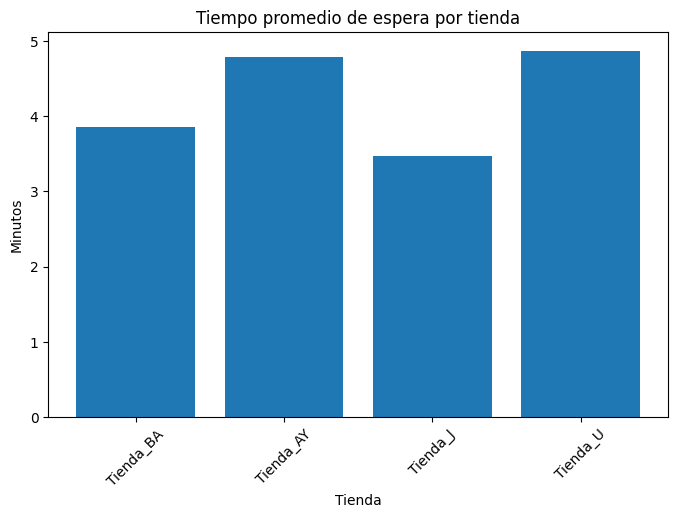

In [16]:
plt.figure(figsize=(8,5))
plt.bar(tienda_kpis["tienda"], tienda_kpis["tiempo_espera_promedio"])
plt.title("Tiempo promedio de espera por tienda")
plt.xlabel("Tienda")
plt.ylabel("Minutos")
plt.xticks(rotation=45)
plt.show()

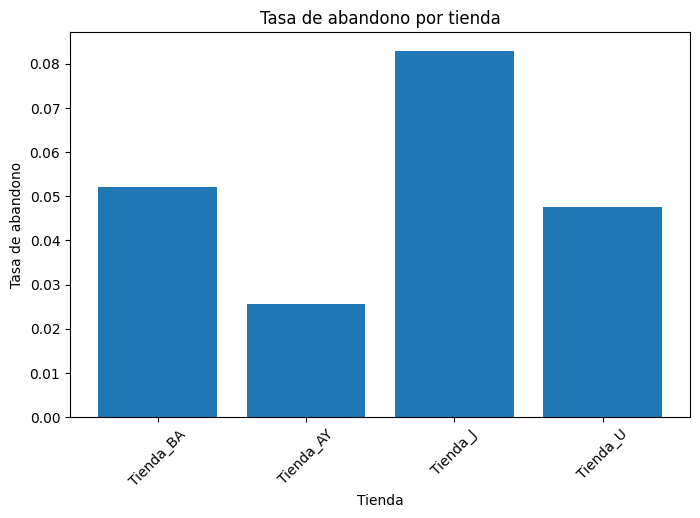

In [17]:
plt.figure(figsize=(8,5))
plt.bar(tienda_kpis["tienda"], tienda_kpis["tasa_abandono"])
plt.title("Tasa de abandono por tienda")
plt.xlabel("Tienda")
plt.ylabel("Tasa de abandono")
plt.xticks(rotation=45)
plt.show()

4. Análisis por segmento

In [18]:
segmento_kpis = df.groupby("Segmento").agg(
    total_clientes=("status", "count"),
    clientes_atendidos=("status", lambda x: (x == "Atendido").sum()),
    clientes_ausentes=("status", lambda x: (x == "Ausente").sum()),
    tiempo_espera_promedio=("tiempo_espera_min", "mean"),
    tiempo_atencion_promedio=("tiempo_atencion_min", "mean")
).reset_index()

segmento_kpis["tasa_abandono"] = segmento_kpis["clientes_ausentes"] / segmento_kpis["total_clientes"]

segmento_kpis = segmento_kpis.sort_values("total_clientes", ascending=False)

segmento_kpis

,Segmento,total_clientes,clientes_atendidos,clientes_ausentes,tiempo_espera_promedio,tiempo_atencion_promedio,tasa_abandono
2,retail,684118,657035,27083,1.965681,2.642618,0.039588
1,banco,629412,597358,32054,5.310711,2.375061,0.050927
0,afiliacion,93795,80446,13349,13.296667,9.613159,0.142321


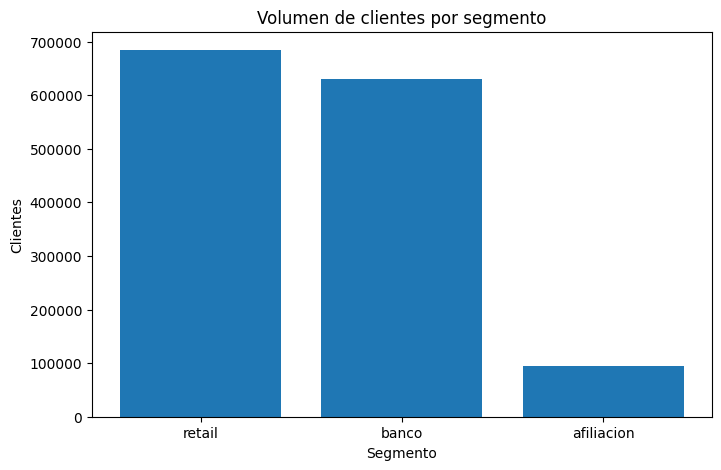

In [19]:
plt.figure(figsize=(8,5))
plt.bar(segmento_kpis["Segmento"], segmento_kpis["total_clientes"])
plt.title("Volumen de clientes por segmento")
plt.xlabel("Segmento")
plt.ylabel("Clientes")
plt.show()

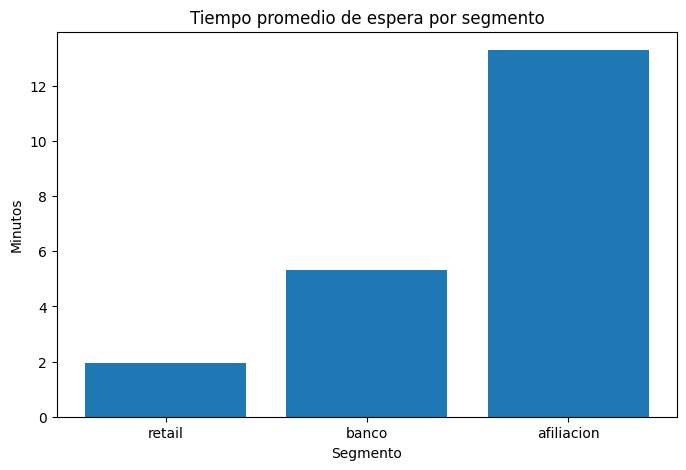

In [20]:
plt.figure(figsize=(8,5))
plt.bar(segmento_kpis["Segmento"], segmento_kpis["tiempo_espera_promedio"])
plt.title("Tiempo promedio de espera por segmento")
plt.xlabel("Segmento")
plt.ylabel("Minutos")
plt.show()

5. Tendencia mensual

In [21]:
mensual = df.groupby("periodo_mes").agg(
    total_clientes=("status", "count"),
    clientes_ausentes=("status", lambda x: (x == "Ausente").sum()),
    tiempo_espera_promedio=("tiempo_espera_min", "mean"),
    tiempo_atencion_promedio=("tiempo_atencion_min", "mean")
).reset_index()

mensual["tasa_abandono"] = mensual["clientes_ausentes"] / mensual["total_clientes"]

mensual

,periodo_mes,total_clientes,clientes_ausentes,tiempo_espera_promedio,tiempo_atencion_promedio,tasa_abandono
0,2023-01,56480,724,3.160786,2.727961,0.012819
1,2023-02,93221,2823,2.907464,2.999113,0.030283
2,2023-03,106802,2908,3.187067,2.978364,0.027228
3,2023-04,104229,3598,3.317516,2.965465,0.034520
4,2023-05,113830,5210,3.171610,2.904840,0.045770
5,2023-06,114049,5165,3.054481,3.063351,0.045288
6,2023-07,123232,6284,3.913523,3.069286,0.050993
7,2023-08,119081,6706,5.145528,3.093749,0.056315
8,2023-09,110874,6652,5.481688,3.076030,0.059996
9,2023-10,112292,7261,5.585242,2.968223,0.064662


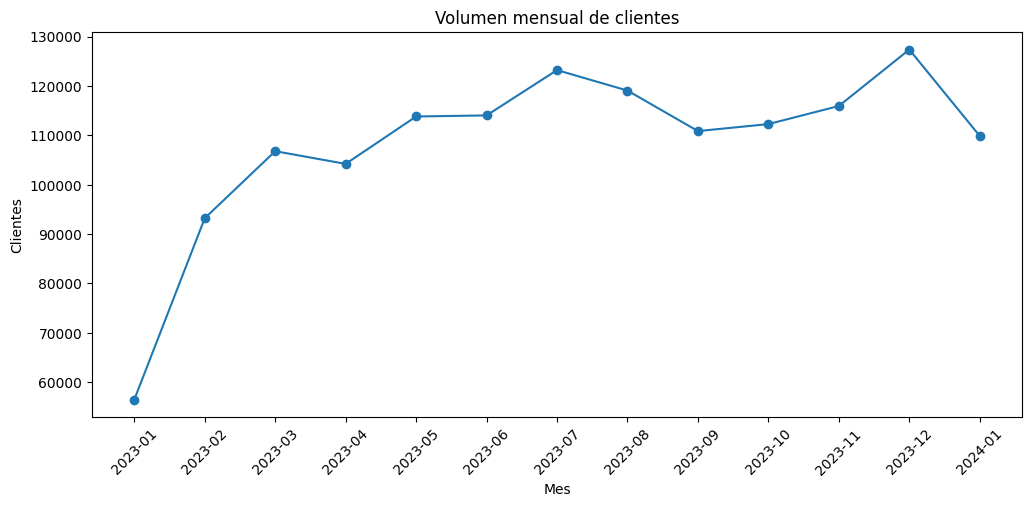

In [22]:
plt.figure(figsize=(12,5))
plt.plot(mensual["periodo_mes"], mensual["total_clientes"], marker="o")
plt.title("Volumen mensual de clientes")
plt.xlabel("Mes")
plt.ylabel("Clientes")
plt.xticks(rotation=45)
plt.show()

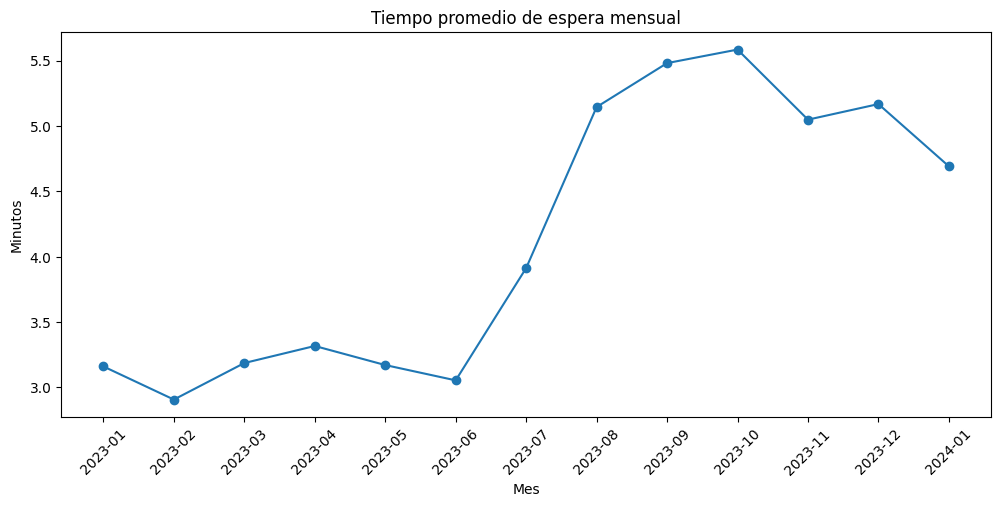

In [23]:
plt.figure(figsize=(12,5))
plt.plot(mensual["periodo_mes"], mensual["tiempo_espera_promedio"], marker="o")
plt.title("Tiempo promedio de espera mensual")
plt.xlabel("Mes")
plt.ylabel("Minutos")
plt.xticks(rotation=45)
plt.show()

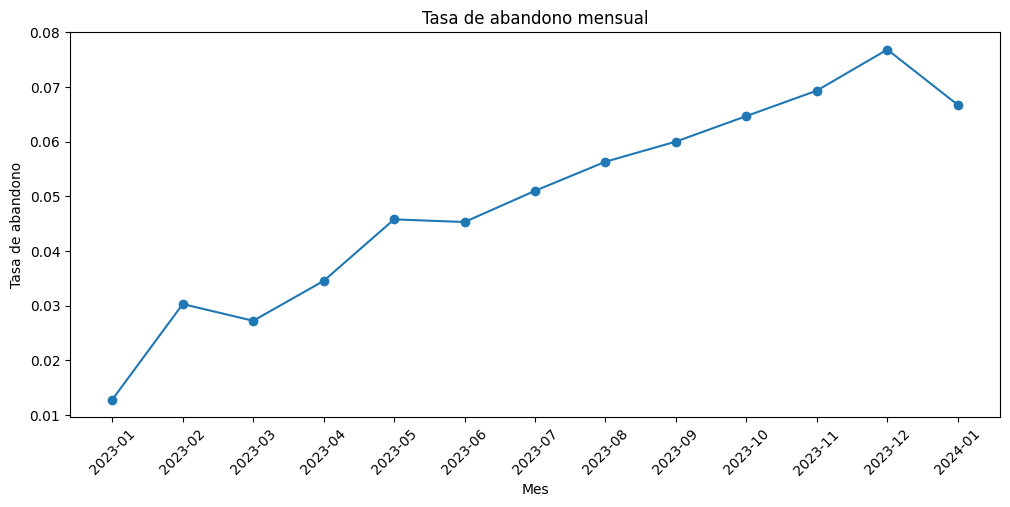

In [24]:
plt.figure(figsize=(12,5))
plt.plot(mensual["periodo_mes"], mensual["tasa_abandono"], marker="o")
plt.title("Tasa de abandono mensual")
plt.xlabel("Mes")
plt.ylabel("Tasa de abandono")
plt.xticks(rotation=45)
plt.show()

6. Análisis por día de la semana

In [25]:
dias_orden = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

dia_kpis = df.groupby("dia_semana").agg(
    total_clientes=("status", "count"),
    tiempo_espera_promedio=("tiempo_espera_min", "mean"),
    tasa_abandono=("status", lambda x: (x == "Ausente").mean())
).reset_index()

dia_kpis["dia_semana"] = pd.Categorical(dia_kpis["dia_semana"], categories=dias_orden, ordered=True)
dia_kpis = dia_kpis.sort_values("dia_semana")

dia_kpis

,dia_semana,total_clientes,tiempo_espera_promedio,tasa_abandono
1,Monday,237490,4.972692,0.054731
5,Tuesday,206914,4.462476,0.053394
6,Wednesday,182868,3.763008,0.049768
4,Thursday,167546,3.389486,0.045379
0,Friday,178809,3.534104,0.048023
2,Saturday,236674,4.575776,0.053994
3,Sunday,197024,4.361423,0.052633


7. Análisis por caja

In [26]:
caja_kpis = df.groupby(["tienda", "caja"]).agg(
    total_clientes=("status", "count"),
    tiempo_espera_promedio=("tiempo_espera_min", "mean"),
    tiempo_atencion_promedio=("tiempo_atencion_min", "mean"),
    tasa_abandono=("status", lambda x: (x == "Ausente").mean())
).reset_index()

caja_kpis = caja_kpis.sort_values("total_clientes", ascending=False)

caja_kpis.head(20)

,tienda,caja,total_clientes,tiempo_espera_promedio,tiempo_atencion_promedio,tasa_abandono
64,Tienda_J,caja_d,44198,3.133677,2.184315,0.109326
18,Tienda_AY,ventanilla_a,43026,8.298982,2.699836,0.028936
66,Tienda_J,caja_f,42795,2.964760,2.247147,0.113027
74,Tienda_J,ventanilla_a,42030,2.404660,1.991939,0.038734
19,Tienda_AY,ventanilla_b,40790,7.840750,2.591398,0.034567
92,Tienda_U,ventanilla_d,38646,4.843689,2.324392,0.030249
77,Tienda_J,ventanilla_d,38603,2.432860,1.931862,0.039038
21,Tienda_AY,ventanilla_d,38280,7.916692,2.715843,0.020402
63,Tienda_J,caja_c,37898,3.028312,2.310413,0.095177
6,Tienda_AY,caja_h,36308,1.497723,2.447750,0.016994


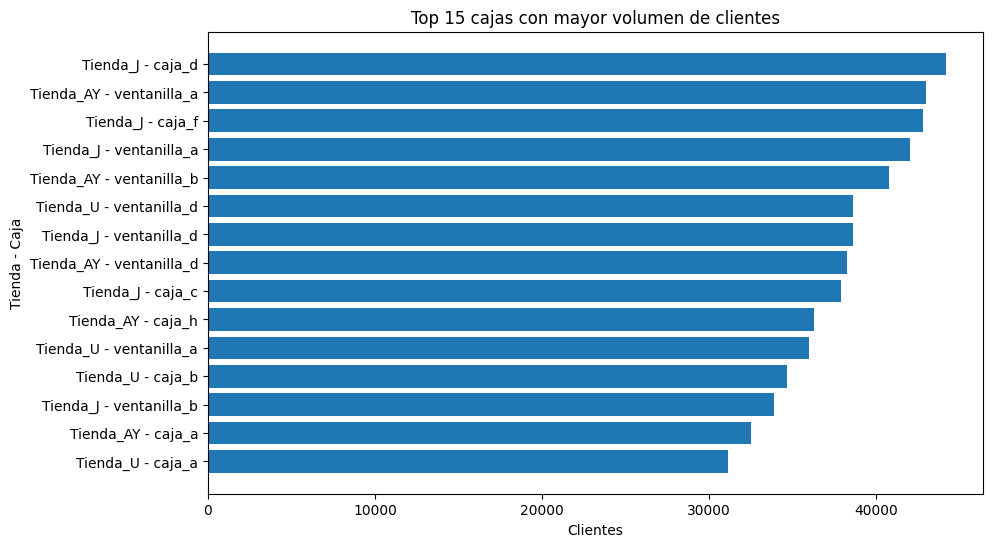

In [27]:
# Cajas con mayor volumen
top_cajas = caja_kpis.head(15).copy()
top_cajas["tienda_caja"] = top_cajas["tienda"] + " - " + top_cajas["caja"]

plt.figure(figsize=(10,6))
plt.barh(top_cajas["tienda_caja"], top_cajas["total_clientes"])
plt.title("Top 15 cajas con mayor volumen de clientes")
plt.xlabel("Clientes")
plt.ylabel("Tienda - Caja")
plt.gca().invert_yaxis()
plt.show()

8. Análisis de problemas o mismatch

In [28]:
mismatch_analysis = df.groupby("mismatch_reason").agg(
    total_registros=("status", "count"),
    tiempo_espera_promedio=("tiempo_espera_min", "mean"),
    tiempo_atencion_promedio=("tiempo_atencion_min", "mean"),
    tasa_abandono=("status", lambda x: (x == "Ausente").mean())
).reset_index()

mismatch_analysis = mismatch_analysis.sort_values("total_registros", ascending=False)

mismatch_analysis

,mismatch_reason,total_registros,tiempo_espera_promedio,tiempo_atencion_promedio,tasa_abandono
3,unico,1311640,4.333355,3.045043,0.046059
0,multitramite,92575,2.328314,2.153367,0.125703
2,saturacion,2997,11.529591,3.622296,0.143477
1,otro_caso,113,5.703687,1.920527,0.053097


9. Insights

In [29]:
tienda_mayor_volumen = tienda_kpis.sort_values("total_clientes", ascending=False).iloc[0]
tienda_mayor_espera = tienda_kpis.sort_values("tiempo_espera_promedio", ascending=False).iloc[0]
segmento_mayor_volumen = segmento_kpis.sort_values("total_clientes", ascending=False).iloc[0]
segmento_mayor_espera = segmento_kpis.sort_values("tiempo_espera_promedio", ascending=False).iloc[0]
dia_mayor_volumen = dia_kpis.sort_values("total_clientes", ascending=False).iloc[0]
dia_mayor_espera = dia_kpis.sort_values("tiempo_espera_promedio", ascending=False).iloc[0]

print("INSIGHTS DEL PROYECTO")
print("------------------------------------------------")
print(f"1. La tienda con mayor volumen fue {tienda_mayor_volumen['tienda']} con {tienda_mayor_volumen['total_clientes']:,.0f} registros.")
print(f"2. La tienda con mayor tiempo promedio de espera fue {tienda_mayor_espera['tienda']} con {tienda_mayor_espera['tiempo_espera_promedio']:.2f} minutos.")
print(f"3. El segmento con mayor demanda fue {segmento_mayor_volumen['Segmento']} con {segmento_mayor_volumen['total_clientes']:,.0f} registros.")
print(f"4. El segmento con mayor espera promedio fue {segmento_mayor_espera['Segmento']} con {segmento_mayor_espera['tiempo_espera_promedio']:.2f} minutos.")
print(f"5. El día con mayor volumen fue {dia_mayor_volumen['dia_semana']}.")
print(f"6. El día con mayor espera promedio fue {dia_mayor_espera['dia_semana']}.")
print(f"7. La tasa general de abandono fue {tasa_abandono:.2%}.")

INSIGHTS DEL PROYECTO
------------------------------------------------
1. La tienda con mayor volumen fue Tienda_BA con 420,717 registros.
2. La tienda con mayor tiempo promedio de espera fue Tienda_U con 4.87 minutos.
3. El segmento con mayor demanda fue retail con 684,118 registros.
4. El segmento con mayor espera promedio fue afiliacion con 13.30 minutos.
5. El día con mayor volumen fue Monday.
6. El día con mayor espera promedio fue Monday.
7. La tasa general de abandono fue 5.15%.
